In [1]:

import sys

import dill
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

sys.path.append('FACTMpy')
from build_model import FACTModel  # pyright: ignore[reportMissingImports]

# Data

In [2]:
with open("data/data_factm_2.pkl", "rb") as f:
    data_factm = dill.load(f)

In [3]:
with open("data/data_factm_names_2.pkl", "rb") as f:
    data_features = dill.load(f)

In [4]:
# mofa_no_binary = mfx.mofa_model("mofa_no_binary")
factors_df = pd.read_table('fitted_mofa/factors.txt', sep=' ')
factors_df.index = factors_df.index.str.replace('_','-', regex=True)
factors_mofa = np.array(factors_df)
views_names_mofa = ['cellohood', 'densites', 'interactions', 'expressions', 'rna']
weights_cellohood = np.array(pd.read_table('fitted_mofa/weights_cellohood.txt', sep=' '))
weights_densities = np.array(pd.read_table('fitted_mofa/weights_densities.txt', sep=' '))
weights_expressions = np.array(pd.read_table('fitted_mofa/weights_expressions.txt', sep=' '))
weights_interactions = np.array(pd.read_table('fitted_mofa/weights_interactions.txt', sep=' '))
weights_rna = np.array(pd.read_table('fitted_mofa/weights_rna.txt', sep=' '))
weights_mofa = [weights_cellohood, weights_densities, weights_interactions, weights_expressions, weights_rna]

In [5]:
# BAD VIEW:  view_IF1_stroma
data_factm_small = {'M'+str(i): data_factm['M'+str(i)] for i in range(9)}
data_factm_small['M9'] = data_factm['M10']
data_factm_small['M10'] = data_factm['M11']
data_factm_small['M11'] = data_factm['M12']
data_factm_small['M12'] = data_factm['M13']
data_factm_small['M13'] = data_factm['M14']

In [6]:
# BAD VIEW:  view_IF1_stroma
data_features_small = {'M'+str(i): data_features['M'+str(i)] for i in range(9)}
data_features_small['M9'] = data_features['M10']
data_features_small['M10'] = data_features['M11']
data_features_small['M11'] = data_features['M12']
data_features_small['M12'] = data_features['M13']
data_features_small['M13'] = data_features['M14']

In [7]:
data_factm_small.keys()

dict_keys(['M0', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12', 'M13'])

# Models

## FACTM simple+structured 10 factors

In [8]:
data_factm_small['M0']


array([[-1.31198402, -0.22056469, -1.22044027, ..., -0.23513345,
        -0.17431598, -0.3348767 ],
       [ 0.96840608, -0.25485449,  0.19653759, ..., -0.23513345,
        -0.17431598, -0.3348767 ],
       [ 1.25030234,  0.89249504, -0.97605473, ..., -0.23513345,
        -0.17431598, -0.3348767 ],
       ...,
       [-0.48835027, -0.37341225,  1.08177053, ..., -0.23513345,
        -0.17431598, -0.3348767 ],
       [        nan,         nan,         nan, ..., -0.23513345,
        -0.17431598, -0.3348767 ],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]], shape=(192, 61))

In [9]:
data_factm_small['M0'].shape

(192, 61)

In [10]:
data_factm_small['M10']

[array([[2., 1., 1., ..., 0., 0., 0.],
        [0., 4., 1., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [6., 0., 0., ..., 0., 0., 0.],
        [2., 0., 0., ..., 0., 0., 0.],
        [6., 0., 0., ..., 0., 0., 0.]], shape=(1775, 9), dtype=float32),
 array([[ 0.,  0.,  0., ...,  0.,  1.,  0.],
        [10.,  1.,  0., ...,  0.,  0.,  0.],
        [ 9.,  2.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 6.,  0.,  0., ...,  0.,  0.,  0.],
        [ 5.,  1.,  1., ...,  0.,  0.,  0.],
        [ 5.,  0.,  0., ...,  0.,  0.,  0.]],
       shape=(2403, 9), dtype=float32),
 array([[ 4.,  0.,  0., ...,  0.,  0.,  0.],
        [ 5.,  0.,  0., ...,  0.,  0.,  0.],
        [ 5.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 2.,  0.,  0., ...,  0.,  0.,  0.],
        [ 4.,  0.,  0., ...,  0.,  0.,  0.],
        [11.,  0.,  0., ...,  0.,  1.,  0.]],
       shape=(2665, 9), dtype=float32),
 array([[12.,  1.,  0., ...,  0.,  2.,  0.],
        [ 4.,  0.,  0., ..

In [11]:
len(data_factm_small['M10'])
data_factm_small['M10'][1].shape

(2403, 9)

In [12]:
from model_config import Likelihood, ModelConfig, create_view_configs, WPrior, ZPrior

model_config = ModelConfig(
    view_configs=create_view_configs(
        *[(Likelihood.NORMAL, WPrior.ARD)] * 6,
        *[(Likelihood.CTM, WPrior.NONE, 10)] * 8,
    ),
    z_priors=[ZPrior.STD_NORMAL] * 10,
)

factm = FACTModel(
    data=data_factm_small,
    K=10,
    model_config=model_config,
    seed=123
)

In [13]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining CTM for a modality 6
Pretraining CTM for a modality 7
Pretraining CTM for a modality 8
Pretraining CTM for a modality 9
Pretraining CTM for a modality 10
Pretraining CTM for a modality 11
Pretraining CTM for a modality 12
Pretraining CTM for a modality 13
Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [14]:
# start from MOFA params

factm.fa.node_z.vi_mu[:,:6] = 1.0*factors_mofa
factm.fa.node_z.update_params()

for i in range(5):

    factm.fa.nodelist_hat_w[i].vi_mu[:,:6] = 1.0*weights_mofa[i]
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

for i in range(6, 14):
    mod = LinearRegression(fit_intercept=False)
    mod.fit(factm.fa.node_z.vi_mu, factm.fa.nodelist_y[i].data)
    factm.fa.nodelist_w_not_sparse[i].vi_mu = mod.coef_
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()


factm.fa.nodelist_w[5].update()

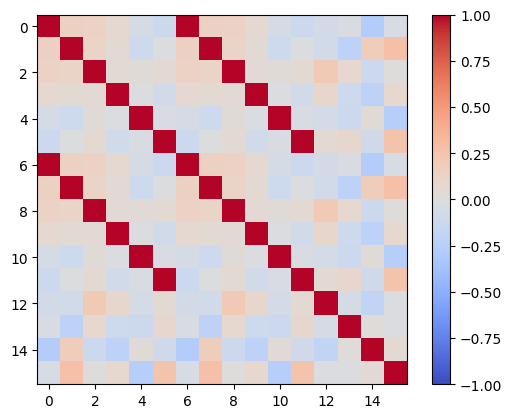

In [15]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factors_mofa.T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

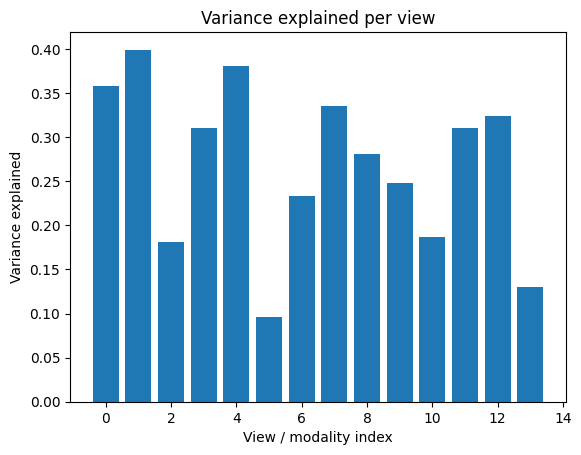

In [16]:
# check 2
factm.fa.node_z.update_params()

for i in range(8):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

variance = factm.fa.variance_explained_per_view()

plt.figure()
plt.bar(range(len(variance)), variance)
plt.xlabel("View / modality index")
plt.ylabel("Variance explained")
plt.title("Variance explained per view")
plt.show()

In [ ]:
factm.fit(50, pretrain=False, elbo_tres=10)

Fitting a model.


  0%|          | 0/50 [00:00<?, ?it/s]

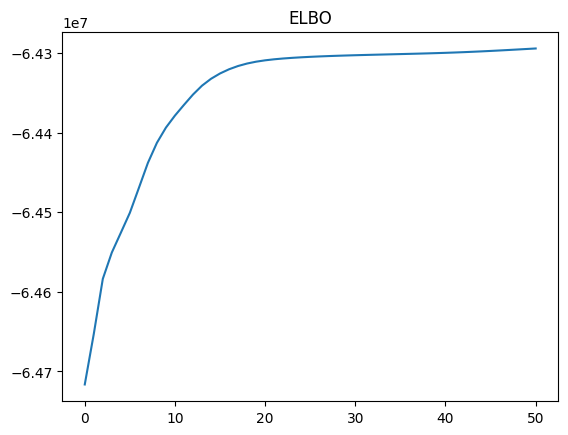

In [ ]:
plt.plot(factm.elbo_sequence)
plt.title('ELBO')
plt.show()


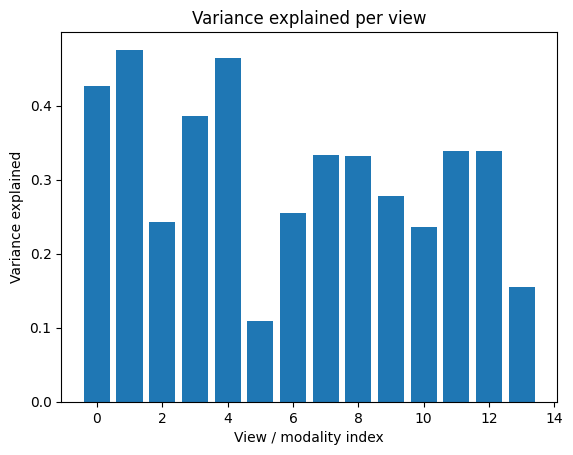

In [ ]:
variance = factm.fa.variance_explained_per_view()

plt.figure()
plt.bar(range(len(variance)), variance)
plt.xlabel("View / modality index")
plt.ylabel("Variance explained")
plt.title("Variance explained per view")
plt.show()

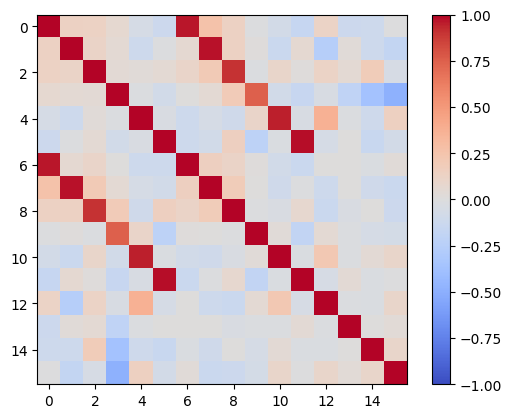

In [ ]:
plt.imshow(
    np.corrcoef(factors_mofa.T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
with open('fitted_factm/models_21_10/factm_all_10.pkl', 'wb') as f:
    dill.dump(factm, f)

FileNotFoundError: [Errno 2] No such file or directory: 'fitted_factm/models_21_10/factm_all_10.pkl'

## FACTM simple+structured 6 factors

In [ ]:
factm = FACTModel(data=data_factm_small, K=6, L=[10,10,10,10,10,10,10,10], 
                  likelihoods=['normal','normal','normal','normal','normal','normal','CTM','CTM','CTM','CTM','CTM','CTM','CTM','CTM'], 
                  W_priors=['ARD','ARD','ARD','ARD','ARD','ARD','None','None','None','None','None','None','None','None'], 
                  seed=123)

In [ ]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining CTM for a modality 6
Pretraining CTM for a modality 7
Pretraining CTM for a modality 8
Pretraining CTM for a modality 9
Pretraining CTM for a modality 10
Pretraining CTM for a modality 11
Pretraining CTM for a modality 12
Pretraining CTM for a modality 13
Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [ ]:
# start from MOFA params

factm.fa.node_z.vi_mu[:,:6] = 1.0*factors_mofa
factm.fa.node_z.update_params()

for i in range(5):

    factm.fa.nodelist_hat_w[i].vi_mu[:,:6] = 1.0*weights_mofa[i]
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

for i in range(6, 14):
    mod = LinearRegression(fit_intercept=False)
    mod.fit(factm.fa.node_z.vi_mu, factm.fa.nodelist_y[i].data)
    factm.fa.nodelist_w_not_sparse[i].vi_mu = mod.coef_
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()


factm.fa.nodelist_w[5].update()

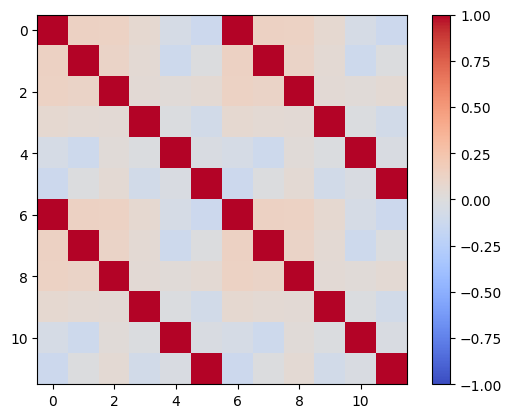

In [ ]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factors_mofa.T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
# check 2
factm.fa.node_z.update_params()

for i in range(8):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

factm.fa.variance_explained_per_view()

array([0.35801845, 0.3987275 , 0.18081157, 0.31035005, 0.38038231,
       0.10376084, 0.15691394, 0.35340592, 0.27449334, 0.24520033,
       0.17833903, 0.23352125, 0.24702086, 0.14992492])

In [ ]:
factm.fit(50, pretrain=False, elbo_tres=10)

Fitting a model.


 14%|█▍        | 7/50 [03:47<23:17, 32.49s/it]


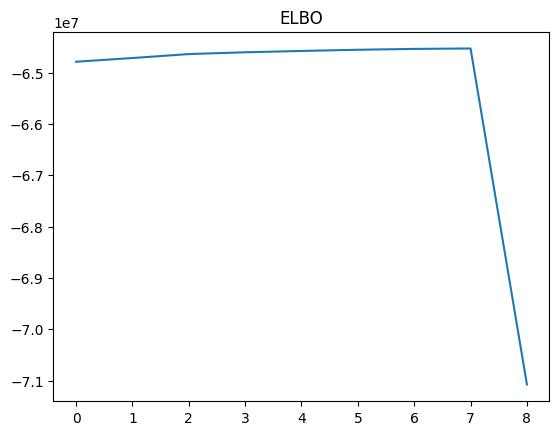

In [ ]:
plt.plot(factm.elbo_sequence)
plt.title('ELBO')
plt.show()


In [ ]:
factm.fa.variance_explained_per_view()

array([ 2.60412971e-01,  3.29736452e-01,  1.40999434e-01,  2.21788868e-01,
        2.93815506e-01,  4.23919473e-02, -2.02525523e+04,  8.86758309e-02,
        2.14510247e-01,  7.89001454e-02, -3.86573185e-02,  2.01079207e-01,
        1.70802072e-01,  1.35786159e-01])

In [ ]:
with open('fitted_factm/models_21_10/factm_all_6.pkl', 'wb') as f:
    dill.dump(factm, f)

## FACTM structured - 10 factors

In [ ]:

data_factm_structured = {'M'+str(i): data_factm['M'+str(i+6)] for i in range(3)}
data_factm_structured.update({
    'M'+str(i+3): data_factm['M'+str(i+10)] for i in range(5)
})

In [ ]:
factm = FACTModel(data=data_factm_structured, K=10, L=[10,10,10,10,10,10,10,10], 
                  likelihoods=['CTM','CTM','CTM','CTM','CTM','CTM','CTM','CTM'], 
                  W_priors=['None','None','None','None','None','None','None','None'], 
                  seed=123)

In [ ]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining CTM for a modality 0
Pretraining CTM for a modality 1
Pretraining CTM for a modality 2
Pretraining CTM for a modality 3
Pretraining CTM for a modality 4
Pretraining CTM for a modality 5
Pretraining CTM for a modality 6
Pretraining CTM for a modality 7
Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [ ]:
# start from MOFA params

factm.fa.node_z.vi_mu[:,:6] = 1.0*factors_mofa
factm.fa.node_z.update_params()

for i in range(8):
    mod = LinearRegression(fit_intercept=False)
    mod.fit(factm.fa.node_z.vi_mu, factm.fa.nodelist_y[i].data)
    factm.fa.nodelist_w_not_sparse[i].vi_mu = mod.coef_
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()


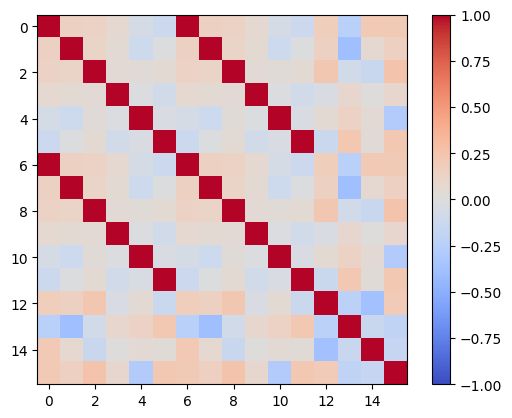

In [ ]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factors_mofa.T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
# check 2
factm.fa.node_z.update_params()

for i in range(8):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

factm.fa.variance_explained_per_view()

array([0.35861832, 0.39931297, 0.18151791, 0.31095385, 0.38091538,
       0.09991491, 0.22693858, 0.33037128, 0.2887182 , 0.2511652 ,
       0.18412641, 0.32247417, 0.32979473, 0.12447947])

In [ ]:
factm.fit(25, pretrain=False, elbo_tres=10)

Fitting a model.


100%|██████████| 25/25 [18:23<00:00, 44.12s/it]


In [ ]:
factm.fa.variance_explained_per_view()

array([0.42651405, 0.47497278, 0.2464054 , 0.38731413, 0.44949956,
       0.10117559, 0.23494595, 0.31480532, 0.31603694, 0.24720136,
       0.24805691, 0.33678966, 0.33364472, 0.1579078 ])

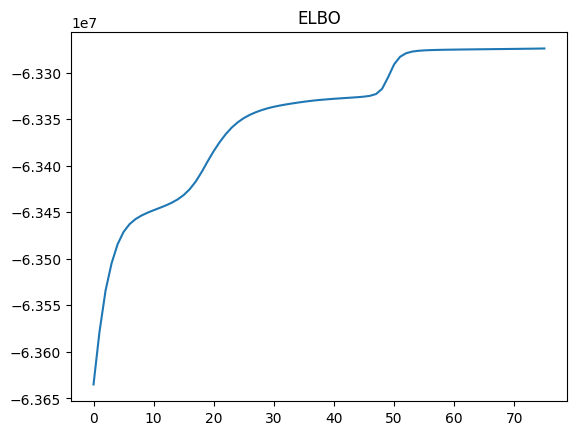

In [ ]:
plt.plot(factm.elbo_sequence)
plt.title('ELBO')
plt.show()


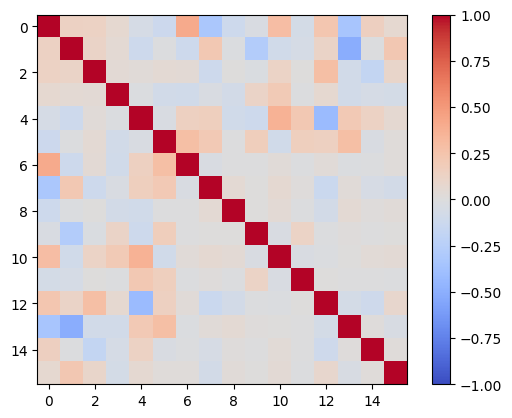

In [ ]:
plt.imshow(
    np.corrcoef(factors_mofa.T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
with open('fitted_factm/models_21_10/factm_structured_10.pkl', 'wb') as f:
    dill.dump(factm, f)

## FACTM structured - 10 factors - start from factm

In [ ]:
data_factm_structured = {'M'+str(i): data_factm['M'+str(i+6)] for i in range(3)}
data_factm_structured.update({
    'M'+str(i+3): data_factm['M'+str(i+10)] for i in range(5)
})

In [ ]:
with open('fitted_factm/models_21_10/factm_all_10.pkl', 'rb') as f:
    factm_all = dill.load(f)

In [ ]:
factm = FACTModel(data=data_factm_structured, K=10, L=[10,10,10,10,10,10,10,10], 
                  likelihoods=['CTM','CTM','CTM','CTM','CTM','CTM','CTM','CTM'], 
                  W_priors=['None','None','None','None','None','None','None','None'], 
                  seed=123)

In [ ]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining CTM for a modality 0
Pretraining CTM for a modality 1
Pretraining CTM for a modality 2
Pretraining CTM for a modality 3
Pretraining CTM for a modality 4
Pretraining CTM for a modality 5
Pretraining CTM for a modality 6
Pretraining CTM for a modality 7
Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [ ]:
# start from MOFA params

factm.fa.node_z.vi_mu = 1.0*factm_all.get_latent_factors()
factm.fa.node_z.update_params()

for i in range(8):
    mod = LinearRegression(fit_intercept=False)
    mod.fit(factm.fa.node_z.vi_mu, factm.fa.nodelist_y[i].data)
    factm.fa.nodelist_w_not_sparse[i].vi_mu = mod.coef_
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()


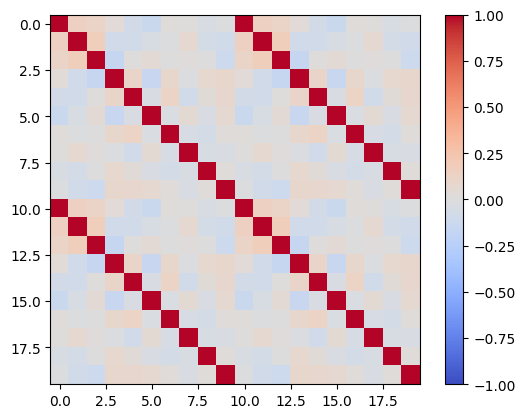

In [ ]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
# check 2
factm.fa.node_z.update_params()

for i in range(8):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

factm.fa.variance_explained_per_view()

array([0.25489334, 0.35230644, 0.35680805, 0.28625886, 0.23652235,
       0.41926019, 0.35325892, 0.20256355])

In [ ]:
factm.fit(25, pretrain=False, elbo_tres=10)

Fitting a model.


100%|██████████| 25/25 [10:35<00:00, 25.42s/it]


In [ ]:
factm.fa.variance_explained_per_view()

array([0.61248733, 0.55375114, 0.38539027, 0.24940942, 0.27497657,
       0.24868357, 0.26768235, 0.56742563])

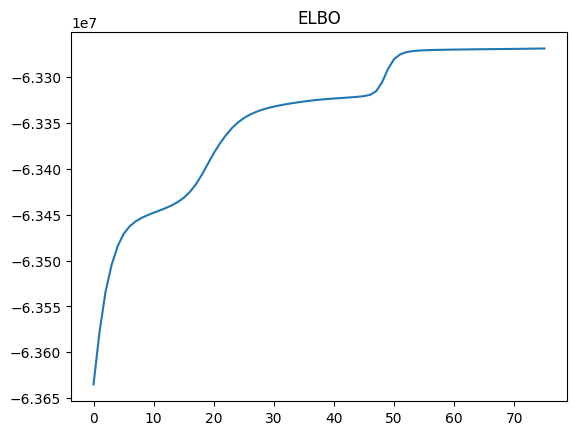

In [ ]:
plt.plot(factm.elbo_sequence)
plt.title('ELBO')
plt.show()


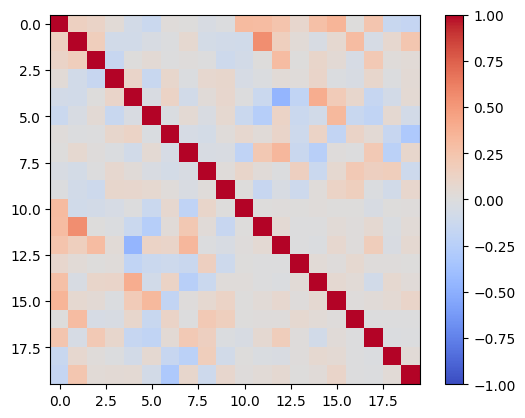

In [ ]:
plt.imshow(
    np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
with open('fitted_factm/models_21_10/factm_structured_10_v2.pkl', 'wb') as f:
    dill.dump(factm, f)

## FACTM simple - 10 factors - start from factm

In [ ]:
data_factm_simple = {'M'+str(i): data_factm['M'+str(i)] for i in range(6)}

In [ ]:
with open('fitted_factm/models_21_10/factm_all_10.pkl', 'rb') as f:
    factm_all = dill.load(f)

In [ ]:
factm = FACTModel(data=data_factm_simple, K=10, L=[], 
                  likelihoods=['normal','normal','normal','normal','normal','normal'], 
                  W_priors=['ARD','ARD','ARD','ARD','ARD','ARD'], 
                  seed=123)

In [ ]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [ ]:
# start from MOFA params

factm.fa.node_z.vi_mu = 1.0*factm_all.get_latent_factors()
factm.fa.node_z.update_params()

for i in range(6):

    factm.fa.nodelist_hat_w[i].vi_mu[:,:] = 1*factm_all.get_loadings(i)
    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()


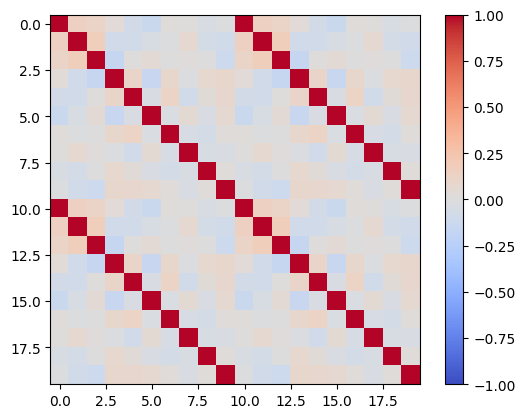

In [ ]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
# check 2
factm.fa.node_z.update_params()

for i in range(6):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

factm.fa.variance_explained_per_view()

array([0.43044284, 0.48077615, 0.24485325, 0.38692356, 0.44770578,
       0.10826598])

In [ ]:
factm.fit(25, pretrain=False, elbo_tres=1)

Fitting a model.


100%|██████████| 25/25 [00:56<00:00,  2.25s/it]


In [ ]:
factm.fa.variance_explained_per_view()

array([0.42867529, 0.47851052, 0.24500922, 0.38570828, 0.44492373,
       0.10974353])

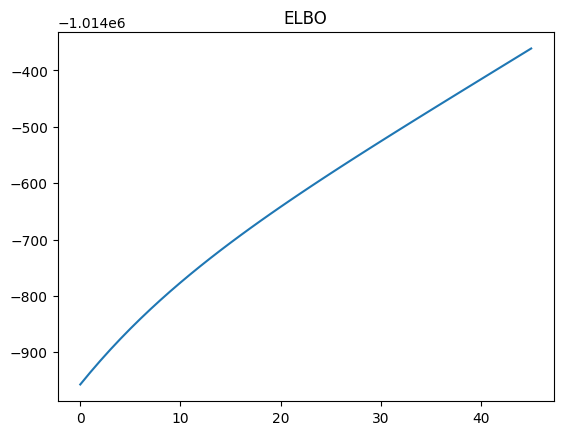

In [ ]:
plt.plot(factm.elbo_sequence[30:])
plt.title('ELBO')
plt.show()


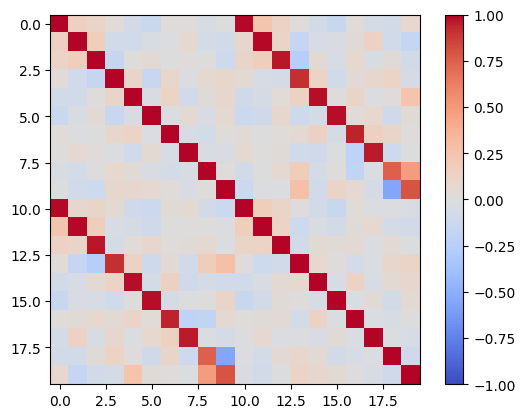

In [ ]:
plt.imshow(np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.show()

In [ ]:
with open('fitted_factm/models_21_10/factm_simple_10_v2.pkl', 'wb') as f:
    dill.dump(factm, f)

## FACTM RNA - 10 factors - start from factm

In [ ]:
data_factm['M2'].shape

(192, 3099)

In [ ]:
data_factm_simple = {'M0': data_factm['M4'],
                     'M1': data_factm['M2']}

In [ ]:
with open('fitted_factm/models_21_10/factm_all_10.pkl', 'rb') as f:
    factm_all = dill.load(f)

In [ ]:
factm = FACTModel(data=data_factm_simple, K=10, L=[], 
                  likelihoods=['normal', 'normal'], 
                  W_priors=['ARD', 'ARD'], 
                  seed=123)

In [ ]:
factm.fit(0, pretrain=True, elbo_tres=10)

Pretraining FA
Fitting a model.


0it [00:00, ?it/s]


In [ ]:
# start from MOFA params

factm.fa.node_z.vi_mu = 1.0 * factm_all.get_latent_factors()
factm.fa.node_z.update_params()

i=0
factm.fa.nodelist_hat_w[i].vi_mu[:,:] = 1 * factm_all.get_loadings(4)
factm.fa.nodelist_w[i].update_params()
factm.fa.nodelist_w[i].update_params_z()
i=1
factm.fa.nodelist_hat_w[i].vi_mu[:,:] = 1 * factm_all.get_loadings(2)
factm.fa.nodelist_w[i].update_params()
factm.fa.nodelist_w[i].update_params_z()

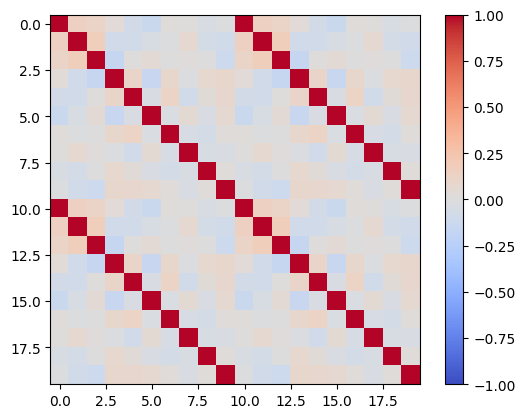

In [ ]:
# check

# plt.imshow(np.corrcoef(mofa_no_binary.get_factors().T, factm.get_latent_factors().T),
# cmap='coolwarm', vmin=-1, vmax=1)
plt.imshow(
    np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
# check 2
factm.fa.node_z.update_params()

for i in range(2):

    factm.fa.nodelist_w[i].update_params()
    factm.fa.nodelist_w[i].update_params_z()

factm.fa.variance_explained_per_view()

array([0.44770578, 0.24485325])

In [ ]:
factm.fit(50, pretrain=False, elbo_tres=1)

Fitting a model.


100%|██████████| 50/50 [01:55<00:00,  2.31s/it]


In [ ]:
factm.fa.variance_explained_per_view()

array([0.45837017, 0.24501248])

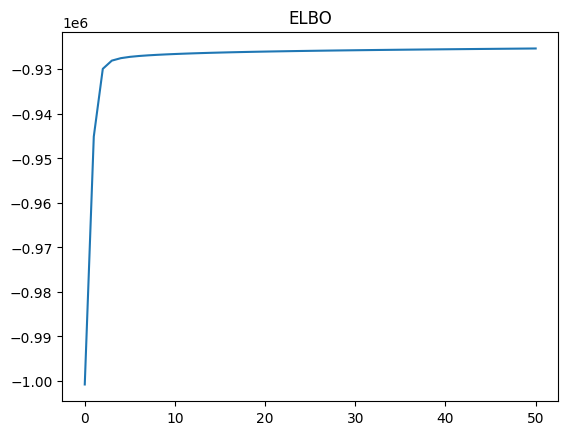

In [ ]:
plt.plot(factm.elbo_sequence[:])
plt.title('ELBO')
plt.show()


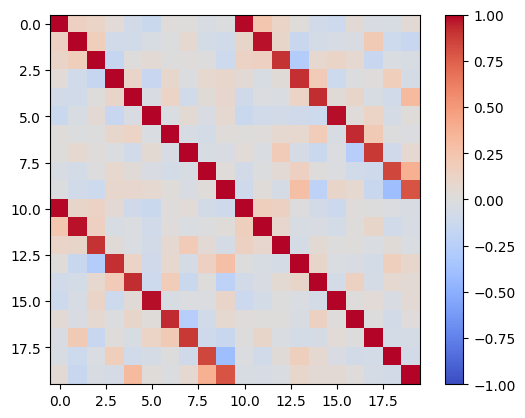

In [ ]:
plt.imshow(
    np.corrcoef(factm_all.get_latent_factors().T, factm.get_latent_factors().T),
    cmap='coolwarm', vmin=-1, vmax=1
)
plt.colorbar()
plt.show()

In [ ]:
with open('fitted_factm/models_21_10/factm_2simple_10_v2.pkl', 'wb') as f:
    dill.dump(factm, f)